In [8]:
!ls "/content/drive/My Drive/Colab Notebooks"

ls: cannot access '/content/drive/My Drive/Colab Notebooks': No such file or directory


<Axes: xlabel='time'>

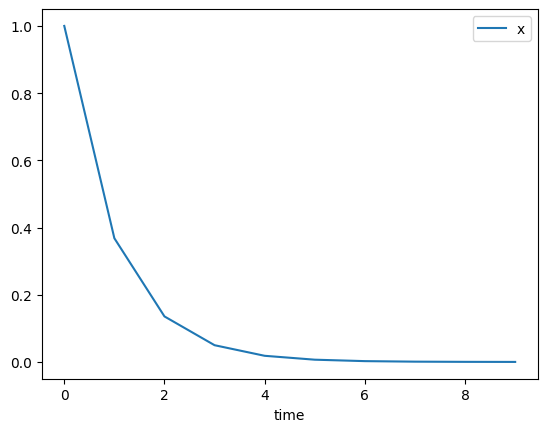

In [ ]:
from poincare import Variable, System, initial, Simulator

class Model(System):
    x: Variable = initial(default=1)
    eq = x.derive() << -x

res = Simulator(Model).solve(save_at=range(10))
res.plot()


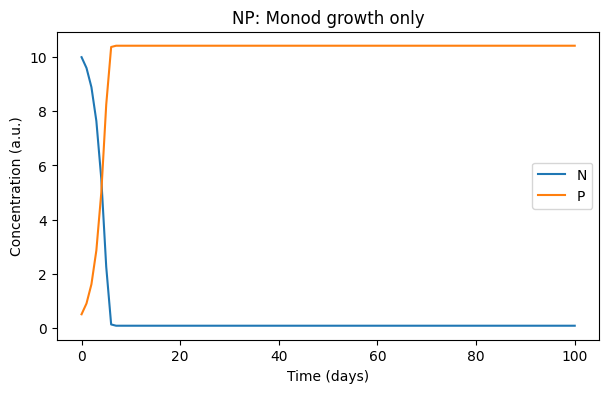

In [ ]:
from poincare import Variable, System, initial, Simulator
import matplotlib.pyplot as plt

class NP(System):
    # States
    N: Variable = initial(default=10.0)
    P: Variable = initial(default=0.5)

    # Params
    mu_max = 0.7
    K_N    = 1.0
    m_P    = 0.05

    # Equations (each in its own attribute!)
    # mu = mu_max * N/(K_N + N)
    eq_N = N.derive() << -(mu_max * N/(K_N + N)) * P + m_P * P
    eq_P = P.derive() <<  (mu_max * N/(K_N + N)) * P - m_P * P

sim = Simulator(NP)
out = sim.solve(save_at=range(0, 101))   # pandas.DataFrame per README
ax = out.plot(figsize=(7,4), title="NP: Monod growth only")
ax.set_xlabel("Time (days)"); ax.set_ylabel("Concentration (a.u.)")
plt.show()


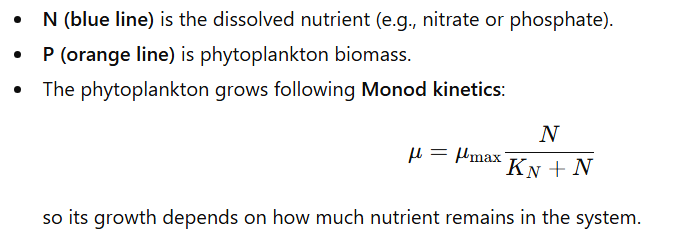

from poincare import Variable, System, initial, Simulator — imports the main Poincaré components: Variable (for dynamic state variables), System (for defining differential equations), initial (for setting starting values), and Simulator (for running the model).

import matplotlib.pyplot as plt — imports Matplotlib’s plotting library to visualize results.

class NP(System): — creates a class called NP that inherits from System, representing the nutrient–phytoplankton model.

N: Variable = initial(default=10.0) — defines nutrient concentration (N) as a state variable with an initial value of 10.0.

P: Variable = initial(default=0.5) — defines phytoplankton biomass (P) as a state variable with an initial value of 0.5.

mu_max = 0.7 — sets the maximum phytoplankton growth rate per day.

K_N = 1.0 — sets the half-saturation constant for nutrient uptake (the value of N where growth is half of mu_max).

m_P = 0.05 — sets the phytoplankton mortality rate per day.

eq_N = N.derive() << -(mu_max * N/(K_N + N)) * P + m_P * P — defines the differential equation for nutrient concentration (dN/dt). The first term (negative) represents nutrient consumption during phytoplankton growth, and the second term (positive) returns nutrients through phytoplankton mortality.

eq_P = P.derive() << (mu_max * N/(K_N + N)) * P - m_P * P — defines the differential equation for phytoplankton biomass (dP/dt). The first term (positive) represents phytoplankton growth using available nutrients, and the second term (negative) represents loss through mortality.

sim = Simulator(NP) — creates a Simulator object to integrate (solve) the NP system over time.

out = sim.solve(save_at=range(0, 101)) — runs the simulation from day 0 to day 100, saving results at each day, returning a DataFrame containing N and P over time.

ax = out.plot(figsize=(7,4), title="NP: Monod growth only") — plots the simulated results of N and P versus time in a 7×4-inch figure with a title.

ax.set_xlabel("Time (days)") — labels the x-axis as time in days.

ax.set_ylabel("Concentration (a.u.)") — labels the y-axis as concentration in arbitrary units.

plt.show() — displays the plotted figure.

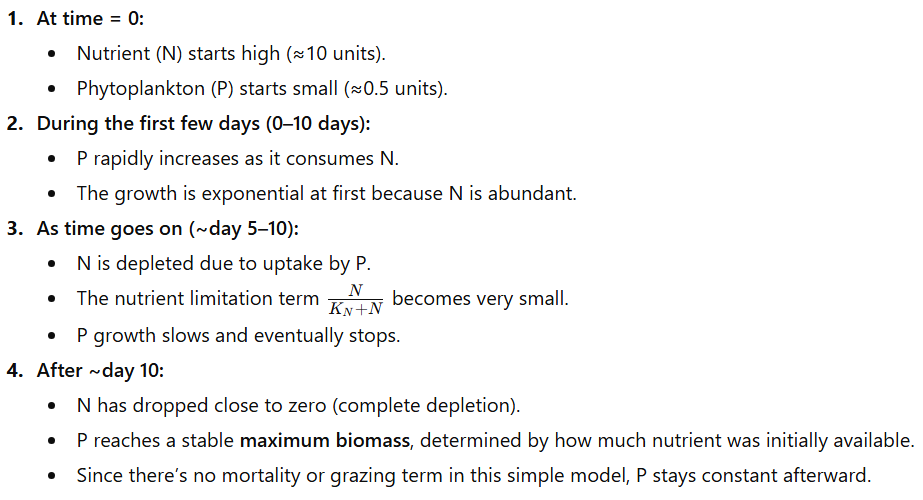

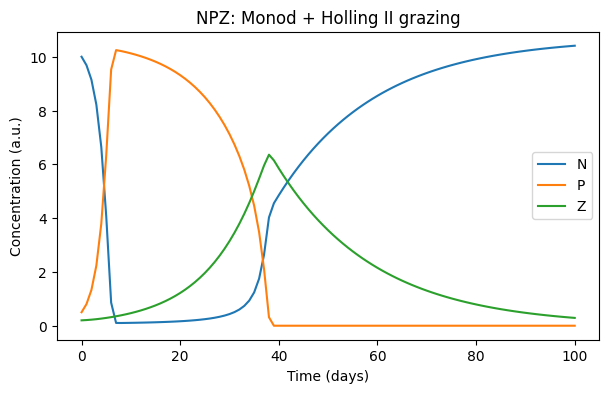

In [ ]:
from poincare import Variable, System, initial, Simulator
import matplotlib.pyplot as plt

class NPZ(System):
    N: Variable = initial(default=10.0)
    P: Variable = initial(default=0.5)
    Z: Variable = initial(default=0.2)

    mu_max = 0.7
    K_N    = 1.0
    m_P    = 0.05

    g_max  = 0.5
    K_P    = 0.3
    eps    = 0.3
    m_Z    = 0.05

    # mu = mu_max * N/(K_N+N)
    # G  = g_max * Z * P/(K_P+P)
    mu = mu_max * N/(K_N + N)
    G  = g_max * Z * (P/(K_P + P))

    eq_N = N.derive() << -mu * P + (1 - eps) * G + m_P*P + m_Z*Z
    eq_P = P.derive() <<  mu * P - G - m_P*P
    eq_Z = Z.derive() <<  eps * G - m_Z*Z

sim = Simulator(NPZ)
out = sim.solve(save_at=range(0, 101))
ax = out.plot(figsize=(7,4), title="NPZ: Monod + Holling II grazing")
ax.set_xlabel("Time (days)"); ax.set_ylabel("Concentration (a.u.)")
plt.show()


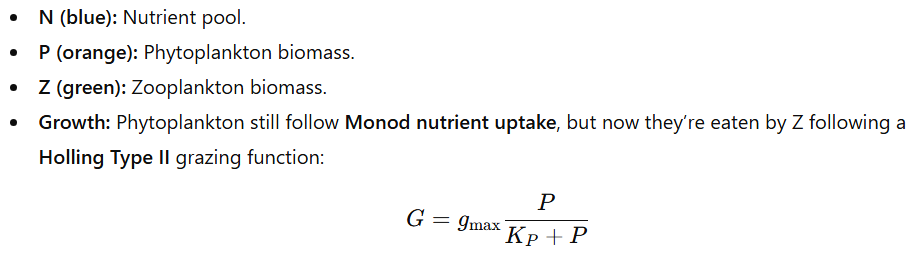

from poincare import Variable, System, initial, Simulator — imports the main Poincaré components for defining and solving the model equations.

import matplotlib.pyplot as plt — imports Matplotlib for plotting.

class NPZ(System): — defines the NPZ model representing nutrient–phytoplankton–zooplankton dynamics.

N: Variable = initial(default=10.0) — declares nutrient concentration with an initial value of 10.0.

P: Variable = initial(default=0.5) — declares phytoplankton biomass with an initial value of 0.5.

Z: Variable = initial(default=0.2) — declares zooplankton biomass with an initial value of 0.2.

mu_max = 0.7, K_N = 1.0, m_P = 0.05 — defines parameters for maximum phytoplankton growth rate, nutrient half-saturation constant, and phytoplankton mortality rate.

g_max = 0.5, K_P = 0.3, eps = 0.3, m_Z = 0.05 — defines zooplankton-related parameters: maximum grazing rate, grazing half-saturation constant, assimilation efficiency, and zooplankton mortality rate.

mu = mu_max * N/(K_N + N) — represents the Monod nutrient-limited phytoplankton growth rate.

G = g_max * Z * (P/(K_P + P)) — represents Holling type II grazing, showing how grazing saturates as prey concentration increases.

eq_N = N.derive() << -mu * P + (1 - eps) * G + m_P * P + m_Z * Z — defines the nutrient equation (dN/dt): nutrients decrease by phytoplankton uptake, but increase through unassimilated grazing and organism mortality.

eq_P = P.derive() << mu * P - G - m_P * P — defines the phytoplankton equation (dP/dt): phytoplankton increase through nutrient uptake and decrease through grazing and mortality.

eq_Z = Z.derive() << eps * G - m_Z * Z — defines the zooplankton equation (dZ/dt): zooplankton gain from assimilated grazing and lose through mortality.

sim = Simulator(NPZ) — initializes a simulator for solving the NPZ system.

out = sim.solve(save_at=range(0, 101)) — runs the simulation from day 0 to 100, saving results each day.

ax = out.plot(figsize=(7,4), title="NPZ: Monod + Holling II grazing") — plots the time evolution of nutrients, phytoplankton, and zooplankton.

ax.set_xlabel("Time (days)") — labels the x-axis as time in days.

ax.set_ylabel("Concentration (a.u.)") — labels the y-axis as concentration in arbitrary units.

plt.show() — displays the plot on screen.

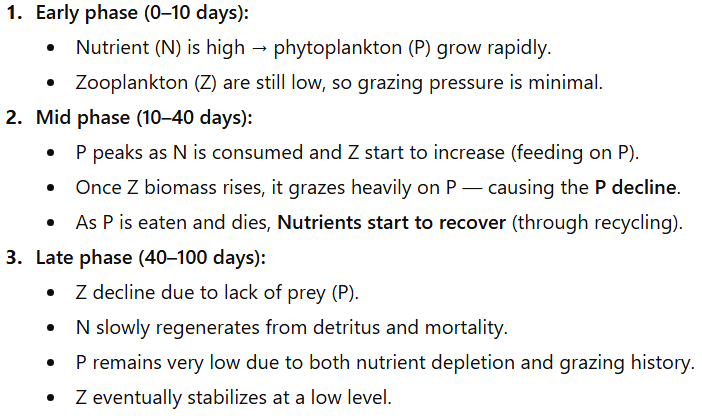

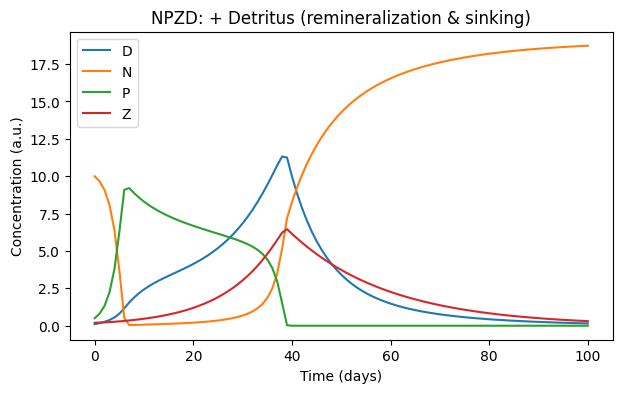

In [ ]:
from poincare import Variable, System, initial, Simulator
import matplotlib.pyplot as plt

class NPZD(System):
    N: Variable = initial(default=10.0)
    P: Variable = initial(default=0.5)
    Z: Variable = initial(default=0.2)
    D: Variable = initial(default=0.1)

    mu_max = 0.7
    K_N    = 1.0
    m_P    = 0.05
    g_max  = 0.5
    K_P    = 0.3
    eps    = 0.3
    m_Z    = 0.05
    r      = 0.1   # remineralization
    s      = 0.05  # sinking/export

    mu = mu_max * N/(K_N + N)
    G  = g_max * Z * (P/(K_P + P))

    eq_N = N.derive() << -mu*P + r*D + (1 - eps) * G
    eq_P = P.derive() <<  mu*P - G - m_P*P
    eq_Z = Z.derive() <<  eps*G - m_Z*Z
    eq_D = D.derive() <<  m_P*P + m_Z*Z + (1-eps)*G - r*D - s*D

sim = Simulator(NPZD)
out = sim.solve(save_at=range(0, 101))
ax = out.plot(figsize=(7,4), title="NPZD: + Detritus (remineralization & sinking)")
ax.set_xlabel("Time (days)"); ax.set_ylabel("Concentration (a.u.)")
plt.show()


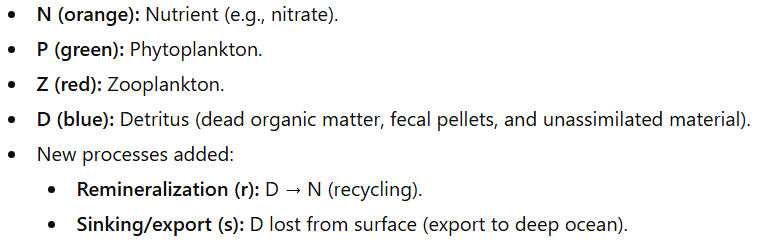

from poincare import Variable, System, initial, Simulator — imports the necessary Poincaré modules for building and solving the model equations.

import matplotlib.pyplot as plt — imports Matplotlib for plotting the model results.

class NPZD(System): — defines the NPZD model, which adds Detritus (D) to the previous NPZ system.

N: Variable = initial(default=10.0) — initializes nutrient concentration at 10.0.

P: Variable = initial(default=0.5) — initializes phytoplankton biomass at 0.5.

Z: Variable = initial(default=0.2) — initializes zooplankton biomass at 0.2.

D: Variable = initial(default=0.1) — initializes detritus concentration at 0.1.

mu_max = 0.7, K_N = 1.0, m_P = 0.05 — parameters for maximum phytoplankton growth, nutrient half-saturation, and phytoplankton mortality.

g_max = 0.5, K_P = 0.3, eps = 0.3, m_Z = 0.05 — parameters for zooplankton grazing: maximum grazing rate, grazing half-saturation constant, assimilation efficiency, and zooplankton mortality.

r = 0.1 — remineralization rate: fraction of detritus converted back to nutrients.

s = 0.05 — sinking/export rate: fraction of detritus permanently removed from the system.

mu = mu_max * N/(K_N + N) — Monod equation for nutrient-limited phytoplankton growth rate.

G = g_max * Z * (P/(K_P + P)) — Holling type II grazing function showing zooplankton feeding on phytoplankton.

eq_N = N.derive() << -muP + rD + (1 - eps) * G — equation for nutrients (dN/dt): nutrients are consumed by phytoplankton growth (–μP), regenerated from detritus remineralization (+rD), and increased by unassimilated grazing ((1–ε)G).

eq_P = P.derive() << muP - G - m_PP — equation for phytoplankton (dP/dt): growth from nutrient uptake (+μP), loss to grazing (–G), and loss to mortality (–mₚP).

eq_Z = Z.derive() << epsG - m_ZZ — equation for zooplankton (dZ/dt): growth from assimilated grazing (+εG) and loss from mortality (–m_ZZ).

eq_D = D.derive() << m_PP + m_ZZ + (1–eps)G - rD - s*D — equation for detritus (dD/dt): detritus increases from mortality of P and Z and unassimilated grazing, while it decreases through remineralization (–rD) and sinking/export (–sD).

sim = Simulator(NPZD) — creates a simulator for solving the NPZD model.

out = sim.solve(save_at=range(0, 101)) — runs the simulation for 100 days, saving results daily.

ax = out.plot(figsize=(7,4), title="NPZD: + Detritus (remineralization & sinking)") — plots the concentrations of N, P, Z, and D over time with a descriptive title.

ax.set_xlabel("Time (days)") — labels the x-axis as time in days.

ax.set_ylabel("Concentration (a.u.)") — labels the y-axis as concentration in arbitrary units.

plt.show() — displays the plot showing nutrient recycling, plankton growth, and detritus accumulation over time.

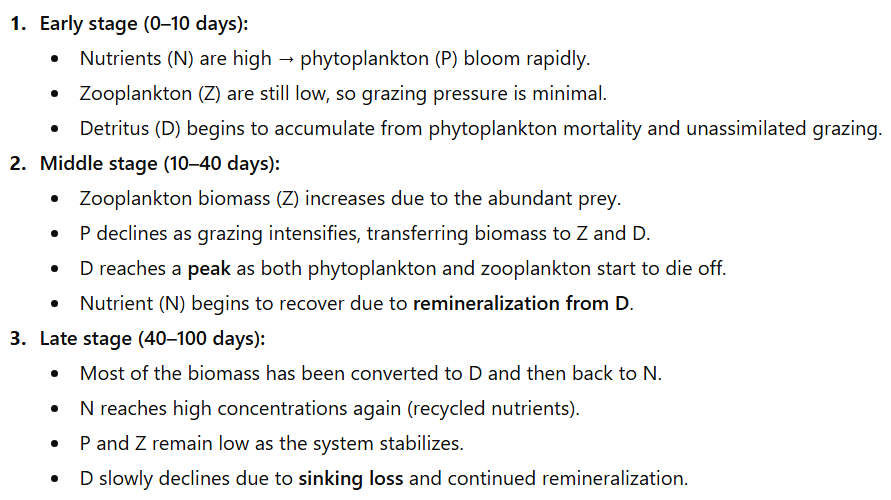

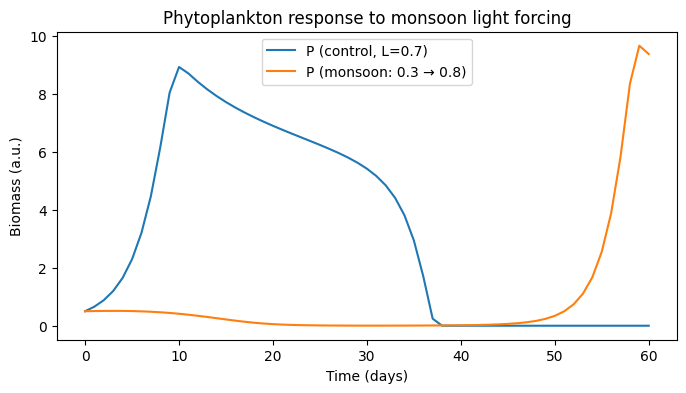

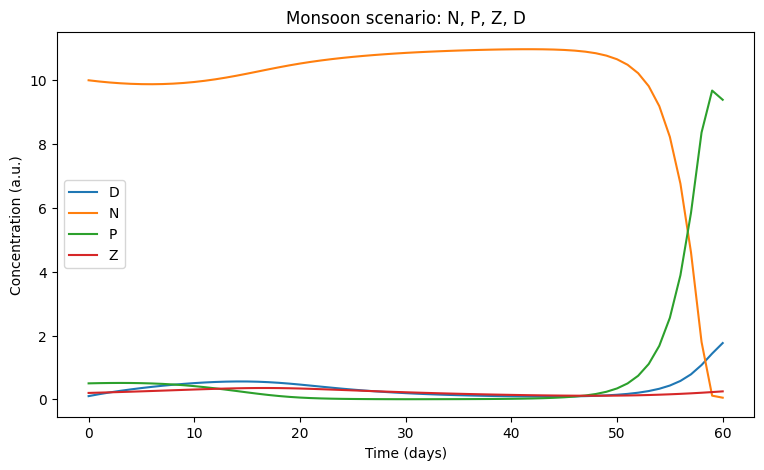

In [ ]:
# --- NPZD with piecewise light forcing (Bay of Bengal monsoon scenario) ---
from poincare import Variable, System, initial, Simulator
import pandas as pd
import matplotlib.pyplot as plt

def make_NPZD_with_light(init=None, L=0.7):
    """Return a NPZD System class with given light factor L and optional initial state dict."""
    # default initial state
    init_default = {"N": 10.0, "P": 0.5, "Z": 0.2, "D": 0.1}
    if init is not None:
        init_default.update(init)

    class NPZD_L(System):
        # --- state variables (initials possibly overridden) ---
        N: Variable = initial(default=init_default["N"])
        P: Variable = initial(default=init_default["P"])
        Z: Variable = initial(default=init_default["Z"])
        D: Variable = initial(default=init_default["D"])

        # --- parameters ---
        mu_max = 0.7
        K_N    = 1.0
        g_max  = 0.5
        K_P    = 0.3
        m_P    = 0.05
        m_Z    = 0.05
        eps    = 0.3
        r      = 0.10
        s      = 0.05
        # light factor (0..1): represents I/(I+K_I)
        Lfac   = L

        # helpers
        mu = mu_max * (N/(K_N + N)) * Lfac
        G  = g_max  * Z * (P/(K_P + P))

        # equations (separate attributes!)
        eq_N = N.derive() << -mu*P + r*D + (1 - eps)*G
        eq_P = P.derive() <<  mu*P - G - m_P*P
        eq_Z = Z.derive() <<  eps*G - m_Z*Z
        eq_D = D.derive() <<  m_P*P + m_Z*Z + (1-eps)*G - r*D - s*D

    return NPZD_L

def run_segment(L, days, init=None):
    Model = make_NPZD_with_light(init=init, L=L)
    sim = Simulator(Model)
    out = sim.solve(save_at=range(days+1))  # include day 0
    return out

# ---- Scenario A: Control (constant light = 0.7 for 60 d) ----
ctrl = run_segment(L=0.7, days=60)

# ---- Scenario B: Monsoon piecewise (0.3 for 0-30 d, then 0.8 for 30-60 d) ----
seg1 = run_segment(L=0.3, days=30)
# use last state of seg1 as initial for seg2
last = seg1.iloc[-1].to_dict()
seg2 = run_segment(L=0.8, days=30, init=last)
# stitch, shifting seg2 time axis to continue after day 30
seg2.index = seg2.index + seg1.index[-1]
mons = pd.concat([seg1, seg2])

# ---- Plots ----
# (1) Compare phytoplankton P only
plt.figure(figsize=(8,4))
ctrl["P"].plot(label="P (control, L=0.7)")
mons["P"].plot(label="P (monsoon: 0.3 → 0.8)")
plt.title("Phytoplankton response to monsoon light forcing")
plt.xlabel("Time (days)"); plt.ylabel("Biomass (a.u.)"); plt.legend(); plt.show()

# (2) Full state evolution for monsoon run
ax = mons.plot(figsize=(9,5), title="Monsoon scenario: N, P, Z, D")
ax.set_xlabel("Time (days)"); ax.set_ylabel("Concentration (a.u.)"); plt.show()


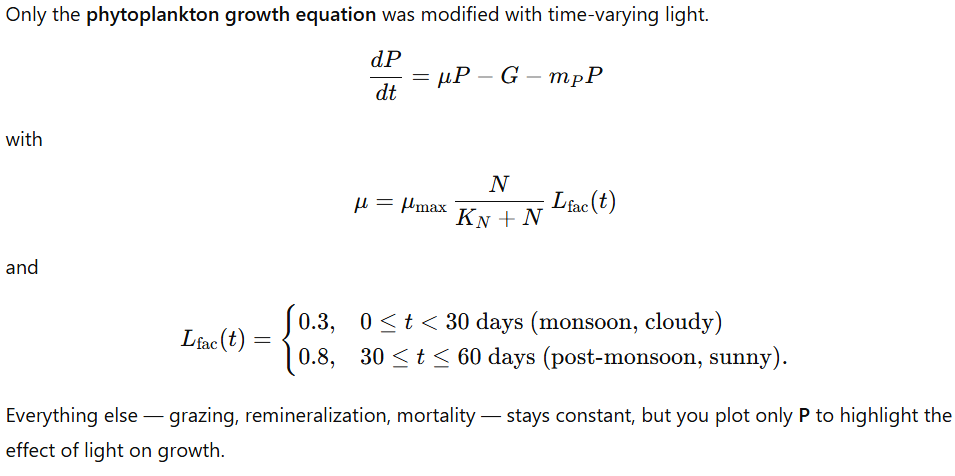

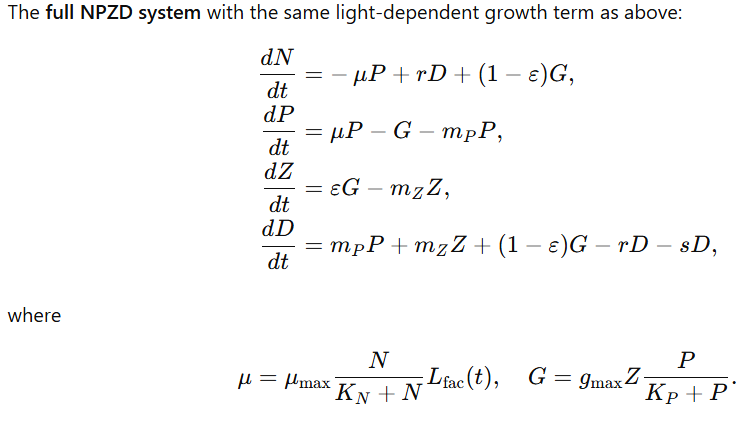

Imports (Poincaré, pandas, Matplotlib) — same roles as before (model definition, tabular handling, plotting).


def make_NPZD_with_light(init=None, L=0.7): — factory function that builds an NPZD class parameterized by a light factor L and optional initial-state overrides init.


init_default = {"N": 10.0, "P": 0.5, "Z": 0.2, "D": 0.1} — base initial conditions for all four state variables.


if init is not None: init_default.update(init) — lets you override any initial value (e.g., start the second segment from the first segment’s last state).


class NPZD_L(System): — defines a per-run NPZD model whose equations use the chosen L.


N, P, Z, D = initial(... from init_default) — sets state-variable initial values, possibly overridden by init.


mu_max, K_N, g_max, K_P, m_P, m_Z, eps, r, s — same biological parameters as earlier NPZD (growth, grazing, mortality, remineralization, sinking).


Lfac = L — stores the light-limitation factor (0–1) inside the class.


mu = mu_max * (N/(K_N + N)) * Lfac — phytoplankton growth rate limited by nutrients (Monod) and scaled by light.


G  = g_max * Z * (P/(K_P + P)) — Holling II grazing term (same as before).


eq_N, eq_P, eq_Z, eq_D — NPZD differential equations exactly as before, now using the light-limited mu.


return NPZD_L — returns the tailor-made class to be simulated.


def run_segment(L, days, init=None): — helper that builds the class for a given L, runs it for days, and returns the output DataFrame.


Model = make_NPZD_with_light(...); sim = Simulator(Model) — constructs the segment-specific model and its simulator.


out = sim.solve(save_at=range(days+1)) — integrates from day 0 to days (inclusive).


Scenario A (control): ctrl = run_segment(L=0.7, days=60) — single 60-day run with constant light 0.7.


Scenario B (monsoon piecewise): seg1 = run_segment(L=0.3, days=30) — first 30 days at low light.


last = seg1.iloc[-1].to_dict() — grab the final state of segment 1 as a dict.


seg2 = run_segment(L=0.8, days=30, init=last) — second 30 days at higher light, starting from seg1’s end state.


seg2.index = seg2.index + seg1.index[-1] — shift seg2’s time index so time continues from day 30 (avoids resetting to zero).


mons = pd.concat([seg1, seg2]) — stitch the two monsoon segments into one continuous time series.


Plot (P only): new figure; plot ctrl["P"] and mons["P"] with labels; title and axes; show — compares bloom timing/magnitude under constant vs monsoon light.


Plot (all states): mons.plot(...) with title and axes — shows N, P, Z, D evolution across the monsoon scenario.




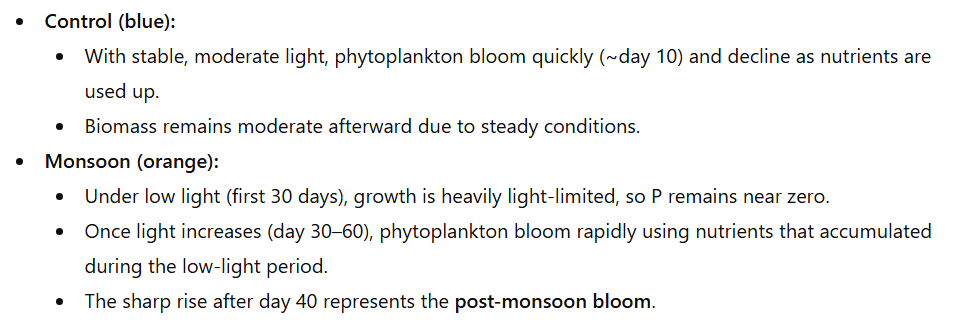

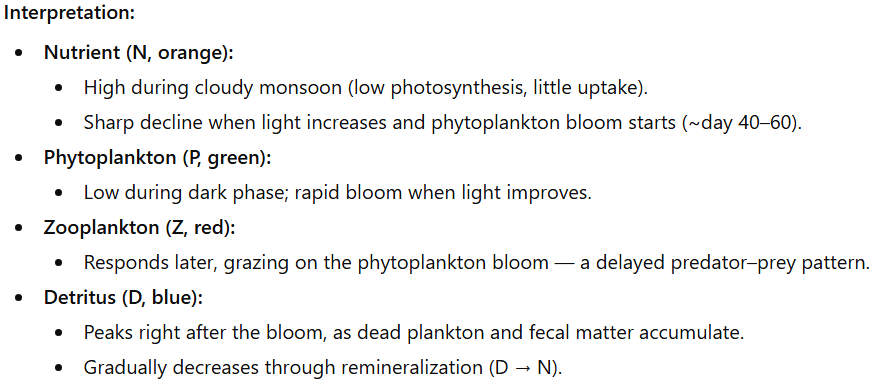

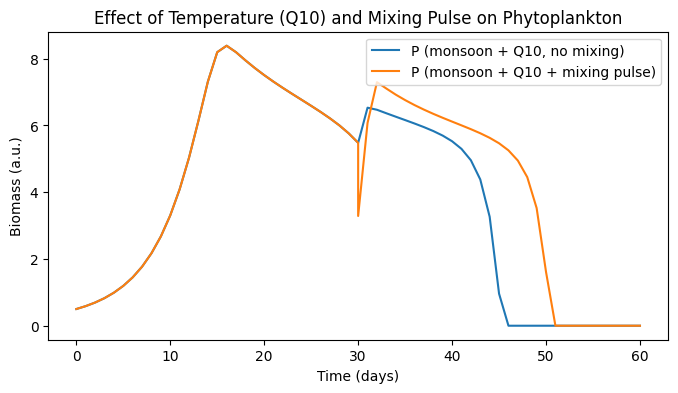

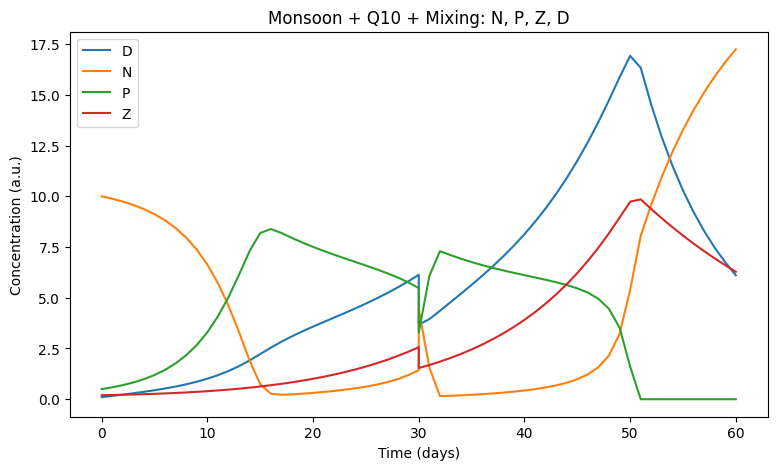

In [ ]:
# --- NPZD with Light + Temperature (Q10) + optional Mixing Pulse ---
from poincare import Variable, System, initial, Simulator
import pandas as pd
import matplotlib.pyplot as plt

# Build NPZD class with light (0–1) and temperature forcing
def make_NPZD_L_T(init=None, L=0.7, Tdeg=28.0, q10_value=2.0):
    init_default = {"N": 10.0, "P": 0.5, "Z": 0.2, "D": 0.1}
    if init is not None:
        init_default.update(init)

    class NPZD_LT(System):
        # --- state variables ---
        N: Variable = initial(default=init_default["N"])
        P: Variable = initial(default=init_default["P"])
        Z: Variable = initial(default=init_default["Z"])
        D: Variable = initial(default=init_default["D"])

        # --- parameters ---
        mu_max = 0.7
        K_N    = 1.0
        g_max  = 0.5
        K_P    = 0.3
        m_P    = 0.05
        m_Z    = 0.05
        eps    = 0.3
        r      = 0.10
        s      = 0.05

        # --- environmental forcing ---
        Lfac = L              # light factor (0–1)
        T    = Tdeg            # temperature (°C)
        q10  = q10_value       # temperature sensitivity

        # --- temperature modulation ---
        f_T = q10 ** ((T - 20.0) / 10.0)
        mu  = mu_max * (N / (K_N + N)) * Lfac * f_T
        G   = g_max * Z * (P / (K_P + P))

        # --- dynamics ---
        eq_N = N.derive() << -mu*P + r*D + (1 - eps)*G
        eq_P = P.derive() <<  mu*P - G - m_P*P
        eq_Z = Z.derive() <<  eps*G - m_Z*Z
        eq_D = D.derive() <<  m_P*P + m_Z*Z + (1-eps)*G - r*D - s*D

    return NPZD_LT


def run_segment(L, T, days, init=None, q10_value=2.0):
    Model = make_NPZD_L_T(init=init, L=L, Tdeg=T, q10_value=q10_value)
    sim = Simulator(Model)
    out = sim.solve(save_at=range(days+1))
    return out


def apply_mixing_pulse(state_dict, deltaN=3.0, dilution=0.6):
    """Simulate deep mixing: inject nutrient (+deltaN) and dilute P,Z,D."""
    st = state_dict.copy()
    st["N"] = max(0.0, st["N"] + deltaN)
    for k in ("P", "Z", "D"):
        st[k] = max(0.0, st[k] * dilution)
    return st


# ---- Scenario 1: Monsoon + Q10 (no mixing) ----
seg1_q10 = run_segment(L=0.3, T=28.0, days=30)
last_q10 = seg1_q10.iloc[-1].to_dict()
seg2_q10 = run_segment(L=0.8, T=30.0, days=30, init=last_q10)
seg2_q10.index = seg2_q10.index + seg1_q10.index[-1]
mons_q10 = pd.concat([seg1_q10, seg2_q10])

# ---- Scenario 2: Monsoon + Q10 + Mixing pulse at day 30 ----
seg1_mix = run_segment(L=0.3, T=28.0, days=30)
last_mix = apply_mixing_pulse(seg1_mix.iloc[-1].to_dict(), deltaN=3.0, dilution=0.6)
seg2_mix = run_segment(L=0.8, T=30.0, days=30, init=last_mix)
seg2_mix.index = seg2_mix.index + seg1_mix.index[-1]
mons_q10_mix = pd.concat([seg1_mix, seg2_mix])

# ---- Plot phytoplankton comparison ----
plt.figure(figsize=(8,4))
mons_q10["P"].plot(label="P (monsoon + Q10, no mixing)")
mons_q10_mix["P"].plot(label="P (monsoon + Q10 + mixing pulse)")
plt.title("Effect of Temperature (Q10) and Mixing Pulse on Phytoplankton")
plt.xlabel("Time (days)"); plt.ylabel("Biomass (a.u.)"); plt.legend(); plt.show()

# ---- Full-state plot for mixing case ----
ax = mons_q10_mix.plot(figsize=(9,5), title="Monsoon + Q10 + Mixing: N, P, Z, D")
ax.set_xlabel("Time (days)"); ax.set_ylabel("Concentration (a.u.)"); plt.show()


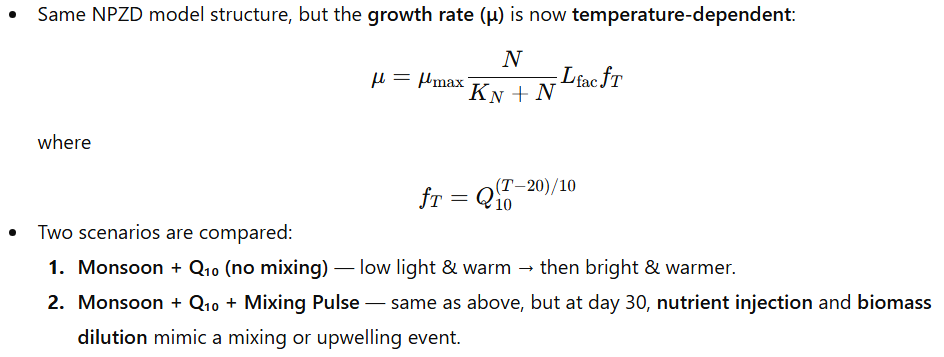

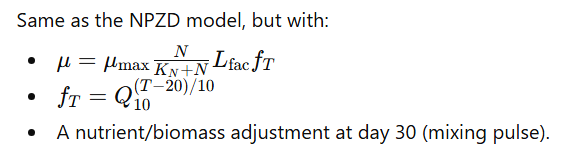

Imports (poincaré, pandas, matplotlib) — same roles as before (model definition/solve, tabular handling, plotting).

def make_NPZD_L_T(init=None, L=0.7, Tdeg=28.0, q10_value=2.0): — factory function that builds an NPZD class configured with light L, temperature Tdeg, optional Q10 value, and optional initial-state overrides.

init_default = {"N": 10.0, "P": 0.5, "Z": 0.2, "D": 0.1} — base initial conditions for all four state variables.

if init is not None: init_default.update(init) — lets a later segment start from a custom state (e.g., previous segment’s last row).

class NPZD_LT(System): — defines a per-run NPZD system whose equations will use the chosen L, Tdeg, and q10_value.

N, P, Z, D = initial(... from init_default) — set state-variable initial values (possibly overridden by init).

mu_max, K_N, g_max, K_P, m_P, m_Z, eps, r, s — same biological parameters as in NPZD (growth, grazing, mortality, remineralization, sinking).

Lfac = L; T = Tdeg; q10 = q10_value — store environmental forcings (light and temperature) and the Q10 sensitivity inside the class.

f_T = q10 ** ((T - 20.0) / 10.0) — Q10 temperature factor: scales rates relative to 20 °C.

mu = mu_max * (N/(K_N + N)) * Lfac * f_T — phytoplankton growth limited by nutrient (Monod), scaled by light and temperature.

G = g_max * Z * (P/(K_P + P)) — Holling type II grazing term (same meaning as before).

eq_N, eq_P, eq_Z, eq_D — NPZD differential equations as before, now driven by light- and temperature-modulated growth mu.

return NPZD_LT — returns the tailored class for simulation.

def run_segment(L, T, days, init=None, q10_value=2.0): — builds the class for a given L, T, (and optional init, q10), simulates days, and returns the results.

Model = make_NPZD_L_T(...); sim = Simulator(Model); out = sim.solve(range(days+1)) — construct, integrate from day 0 to days inclusive, return a DataFrame.

def apply_mixing_pulse(state_dict, deltaN=3.0, dilution=0.6): — mimics a deep-mixing event by adding nutrient (+deltaN to N) and diluting biomasses (P, Z, D multiplied by dilution).

seg1_q10 = run_segment(L=0.3, T=28.0, days=30) — Scenario 1, first half: low light and warm temperature for 30 days (no mixing).

last_q10 = seg1_q10.iloc[-1].to_dict() — capture end state of segment 1.

seg2_q10 = run_segment(L=0.8, T=30.0, days=30, init=last_q10) — Scenario 1, second half: brighter and warmer, starting from previous end state.

seg2_q10.index = seg2_q10.index + seg1_q10.index[-1] — shift second segment’s time index so time continues from day 30.

mons_q10 = pd.concat([seg1_q10, seg2_q10]) — stitch both halves into one continuous series (Scenario 1).

seg1_mix = run_segment(L=0.3, T=28.0, days=30) — Scenario 2, first half identical forcing.

last_mix = apply_mixing_pulse(seg1_mix.iloc[-1].to_dict(), deltaN=3.0, dilution=0.6) — apply mixing pulse at day 30 (nutrient injection + biomass dilution).

seg2_mix = run_segment(L=0.8, T=30.0, days=30, init=last_mix) — Scenario 2, second half with brighter/warmer conditions, starting from pulsed state.

seg2_mix.index = seg2_mix.index + seg1_mix.index[-1]; mons_q10_mix = pd.concat([seg1_mix, seg2_mix]) — align and stitch Scenario 2 segments.

plt.figure(...); mons_q10["P"].plot(...); mons_q10_mix["P"].plot(...); plt.legend(); plt.show() — compare phytoplankton trajectories with/without mixing under identical light/temperature shifts.

mons_q10_mix.plot(...); plt.show() — show full-state evolution (N, P, Z, D) for the mixing case.

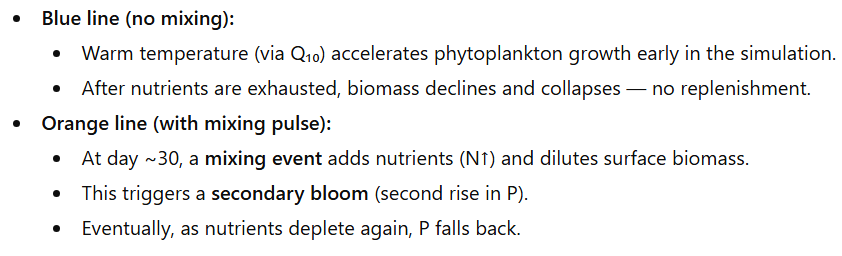

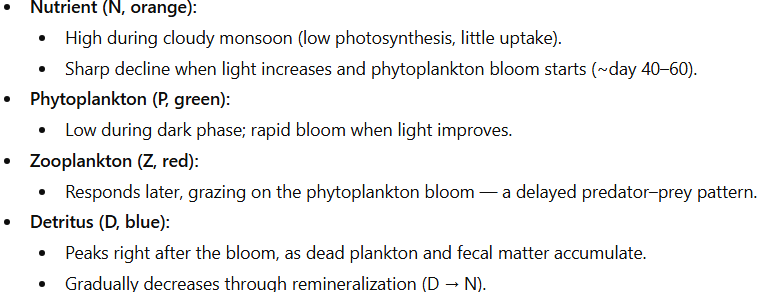

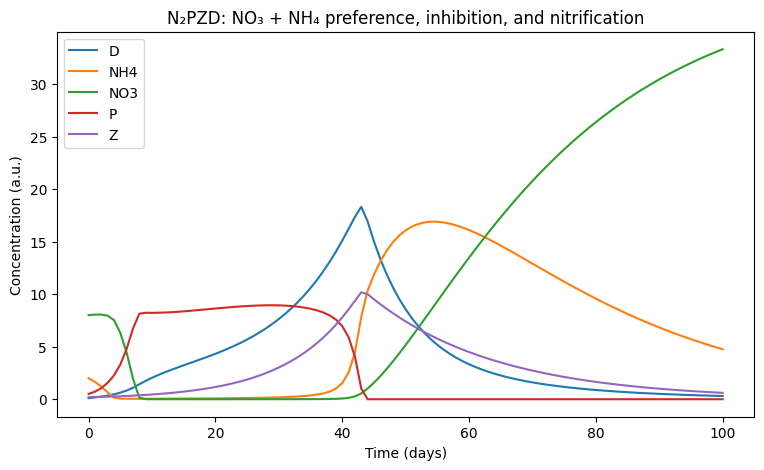

In [ ]:
from poincare import Variable, System, initial, Simulator
import matplotlib.pyplot as plt

class N2PZD(System):
    # states
    NO3: Variable = initial(default=8.0)
    NH4: Variable = initial(default=2.0)
    P:   Variable = initial(default=0.5)
    Z:   Variable = initial(default=0.2)
    D:   Variable = initial(default=0.1)

    # parameters
    mu_max = 0.7
    K_NO3  = 1.0
    K_NH4  = 0.3
    K_I    = 0.2      # NH4 inhibition scale on NO3 uptake
    g_max  = 0.5
    K_P    = 0.3
    eps    = 0.3
    m_P    = 0.05
    m_Z    = 0.05
    r      = 0.10
    s      = 0.05
    nu     = 0.05     # nitrification rate NH4 -> NO3
    Lfac   = 0.8      # simple light factor (0..1)

    # growth components
    mu_NH4 = mu_max * (NH4/(K_NH4 + NH4))
    mu_NO3 = mu_max * (NO3/(K_NO3 + NO3)) * (1/(1 + NH4/K_I))
    mu     = (mu_NH4 + mu_NO3) * Lfac

    # grazing
    G = g_max * Z * (P/(K_P + P))

    # dynamics
    eq_NH4 = NH4.derive() << -mu_NH4*P + r*D + (1 - eps)*G + m_P*P + m_Z*Z - nu*NH4
    eq_NO3 = NO3.derive() << -mu_NO3*P + nu*NH4
    eq_P   = P.derive()   <<  mu*P - G - m_P*P
    eq_Z   = Z.derive()   <<  eps*G - m_Z*Z
    eq_D   = D.derive()   <<  m_P*P + m_Z*Z + (1-eps)*G - r*D - s*D

sim = Simulator(N2PZD)
out = sim.solve(save_at=range(0, 101))
ax = out.plot(figsize=(9,5), title="N₂PZD: NO₃ + NH₄ preference, inhibition, and nitrification")
ax.set_xlabel("Time (days)"); ax.set_ylabel("Concentration (a.u.)")
plt.show()


from poincare import Variable, System, initial, Simulator — imports the Poincaré components to declare variables, define the system, set initials, and run the solver.

import matplotlib.pyplot as plt — loads Matplotlib for plotting.

class N2PZD(System): — defines the model with two nitrogen pools (NO₃, NH₄) plus P, Z, D.

NO3, NH4, P, Z, D as Variables (with defaults) — set initial concentrations for nitrate, ammonium, phytoplankton, zooplankton, and detritus.

mu_max, K_NO3, K_NH4 — growth parameters: maximum rate and half-saturation constants for NO₃ and NH₄ uptake.

K_I — ammonium inhibition scale for nitrate uptake (more NH₄ → stronger inhibition).

g_max, K_P, eps — grazing parameters: maximum rate, prey half-saturation, and assimilation efficiency.

m_P, m_Z — mortality rates of P and Z.

r, s — detritus remineralization and sinking/export rates.

nu — nitrification rate converting NH₄ → NO₃.

Lfac — simple light limitation factor (0–1) multiplying growth.

mu_NH4 = mu_max · NH4/(K_NH4+NH4) — growth supported by ammonium (preferred, no inhibition).

mu_NO3 = mu_max · NO3/(K_NO3+NO3) · 1/(1+NH4/K_I) — growth supported by nitrate but inhibited when NH₄ is present.

mu = (mu_NH4 + mu_NO3) · Lfac — total phytoplankton growth rate reduced by light.

G = g_max · Z · P/(K_P+P) — Holling II grazing by zooplankton on phytoplankton.

eq_NH4: dNH4/dt= recycling from D and mortalities
+
+ unassimilated grazing
−
− NH₄-supported uptake
−
− nitrification.

eq_NO3: dNO3/dt= nitrification input
−
− NO₃-supported uptake (with NH₄ inhibition already embedded in μ_NO3).

eq_P: dP/dt= growth from both N sources (μ·P)
−
− grazing
−
− P mortality.

eq_Z: dZ/dt= assimilated fraction of grazing (ε·G)
−
− Z mortality.

eq_D: dD/dt= mortalities of P and Z plus unassimilated grazing
−
− remineralization
−
− sinking.

sim = Simulator(N2PZD) — creates the solver for this system.

out = sim.solve(save_at=range(0, 101)) — integrates from day 0 to 100, saving daily outputs.

out.plot(...) + labels + plt.show() — plots NO₃, NH₄, P, Z, and D over time; title summarizes NH₄ preference, NO₃ inhibition, and nitrification.

/usr/local/lib/python3.12/dist-packages/poincare/solvers.py:244: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  y = integrate.odeint(


Text(0, 0.5, 'Concentration (a.u.)')

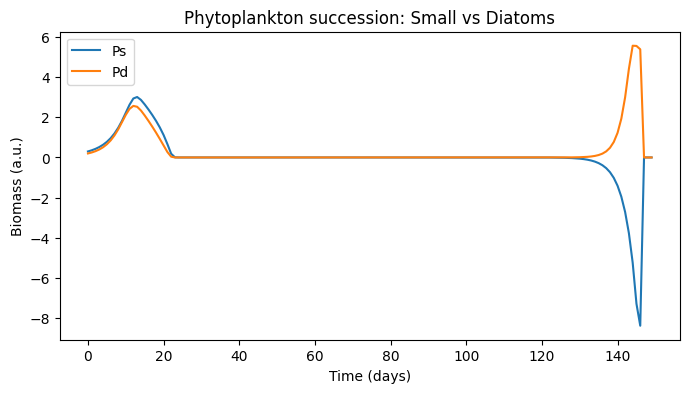

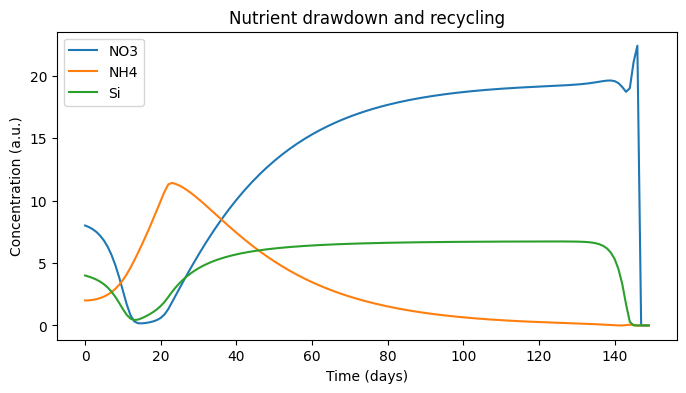

In [ ]:
from poincare import Variable, System, initial, Simulator
import matplotlib.pyplot as plt

class NPZ2DSi(System):
    # --- state variables ---
    NO3: Variable = initial(default=8.0)   # nitrate (uptake source)
    NH4: Variable = initial(default=2.0)   # ammonium (recycling pool)
    Si:  Variable = initial(default=4.0)   # silicate
    Ps:  Variable = initial(default=0.3)   # small phyto (no Si need)
    Pd:  Variable = initial(default=0.2)   # diatoms (need Si)
    Z:   Variable = initial(default=0.2)   # zooplankton
    D:   Variable = initial(default=0.1)   # detritus

    # --- parameters ---
    mu_smax = 0.5
    mu_dmax = 0.8
    K_N   = 1.0
    K_Si  = 1.0
    g_max = 0.6
    K_P   = 0.3
    eps   = 0.3
    m_P   = 0.05
    m_Z   = 0.05
    r     = 0.10
    s     = 0.05
    alpha = 1.5      # grazing preference toward diatoms
    nu    = 0.05     # nitrification NH4 -> NO3
    Lfac  = 0.8

    # --- growth limitation ---
    limN   = NO3 / (K_N  + NO3)
    limSi  = Si  / (K_Si + Si)
    # smooth-maximum of limitation-as-min: min(a,b) ≈ (a*b) / (a + b - a*b)
    eps_min = 1e-12
    minNSi = (limN * limSi) / (limN + limSi - limN*limSi + eps_min)

    mu_s = mu_smax * limN * Lfac
    mu_d = mu_dmax * minNSi * Lfac

    # --- grazing (shared predator with preference) ---
    denom = (K_P + Ps + alpha*Pd)
    Gs = g_max * Z * (Ps / denom)
    Gd = g_max * Z * ((alpha * Pd) / denom)

    # --- dynamics ---
    # NH4: recycling pool with nitrification to NO3 (no direct uptake here)
    eq_NH4 = NH4.derive() << r*D + (1 - eps)*(Gs + Gd) + m_P*(Ps + Pd) + m_Z*Z - nu*NH4
    # NO3: uptake by both groups, replenished by nitrification
    eq_NO3 = NO3.derive() << - (mu_s*Ps + mu_d*Pd) + nu*NH4
    # Si: taken up by diatoms and recycled from detritus
    eq_Si  = Si.derive()  << - mu_d*Pd + r*D
    # Phytoplankton
    eq_Ps  = Ps.derive()  <<   mu_s*Ps - Gs - m_P*Ps
    eq_Pd  = Pd.derive()  <<   mu_d*Pd - Gd - m_P*Pd
    # Zooplankton
    eq_Z   = Z.derive()   <<   eps*(Gs + Gd) - m_Z*Z
    # Detritus
    eq_D   = D.derive()   <<   m_P*(Ps + Pd) + m_Z*Z + (1 - eps)*(Gs + Gd) - r*D - s*D

# simulate
sim = Simulator(NPZ2DSi)
out = sim.solve(save_at=range(0, 150))

# plots
ax = out[['Ps','Pd']].plot(figsize=(8,4), title="Phytoplankton succession: Small vs Diatoms")
ax.set_xlabel("Time (days)"); ax.set_ylabel("Biomass (a.u.)")

ax2 = out[['NO3','NH4','Si']].plot(figsize=(8,4), title="Nutrient drawdown and recycling")
ax2.set_xlabel("Time (days)"); ax2.set_ylabel("Concentration (a.u.)")


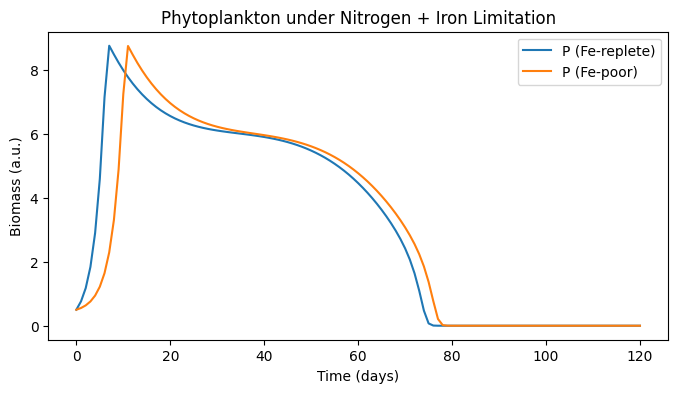

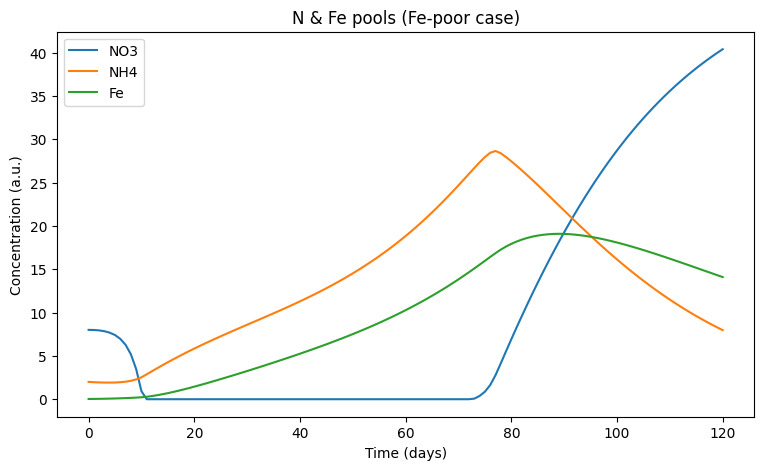

In [ ]:
# === N2PZFeD (Nitrogen + Iron limitation) with class factory ===
from poincare import Variable, System, initial, Simulator
import matplotlib.pyplot as plt

def make_N2PZFeD(fe0=0.30):
    class N2PZFeD(System):
        # --- states ---
        NO3: Variable = initial(default=8.0)
        NH4: Variable = initial(default=2.0)
        Fe:  Variable = initial(default=fe0)   # <- injected by factory
        P:   Variable = initial(default=0.5)
        Z:   Variable = initial(default=0.2)
        D:   Variable = initial(default=0.1)

        # --- parameters (d^-1 unless noted) ---
        mu_max = 0.6
        K_NO3  = 1.5
        K_NH4  = 0.4
        K_Fe   = 0.05
        Lfac   = 0.8

        g_max  = 0.35
        K_P    = 0.5
        eps    = 0.3
        m_P    = 0.04
        m_Z    = 0.05

        r      = 0.06
        s      = 0.02
        nu     = 0.05

        lambda_scav = 0.02
        q_Fe   = 0.005

        # limitation terms
        lim_NO3 = NO3 / (K_NO3 + NO3)
        lim_NH4 = NH4 / (K_NH4 + NH4)
        lim_N   = lim_NH4 + 0.6 * lim_NO3

        lim_Fe  = Fe / (K_Fe + Fe)

        eps_min = 1e-12
        lim_NFe = (lim_N * lim_Fe) / (lim_N + lim_Fe - lim_N*lim_Fe + eps_min)

        # growth & grazing
        mu = mu_max * lim_NFe * Lfac
        G  = g_max * Z * (P / (K_P + P))

        # dynamics
        eq_NH4 = NH4.derive() << r*D + (1 - eps)*G + m_P*P + m_Z*Z - nu*NH4
        eq_NO3 = NO3.derive() << - (mu*P) + nu*NH4

        Fe_remin = r*D*q_Fe/(q_Fe + 1e-12)
        Fe_graz  = (1 - eps)*G*q_Fe
        eq_Fe    = Fe.derive()  << - q_Fe*(mu*P) + Fe_remin + Fe_graz - lambda_scav*Fe

        eq_P = P.derive() <<  mu*P - G - m_P*P
        eq_Z = Z.derive() <<  eps*G - m_Z*Z
        eq_D = D.derive() <<  m_P*P + m_Z*Z + (1 - eps)*G - r*D - s*D
    return N2PZFeD

def run(fe0, days=120):
    Model = make_N2PZFeD(fe0)
    sim = Simulator(Model)
    out = sim.solve(save_at=range(0, days+1))
    out[out < 0] = 0  # small numerical safety
    return out

# Fe-replete vs Fe-poor
fe_high = run(0.30, 120)
fe_low  = run(0.03, 120)

# Plots
plt.figure(figsize=(8,4))
fe_high["P"].plot(label="P (Fe-replete)")
fe_low["P"].plot(label="P (Fe-poor)")
plt.title("Phytoplankton under Nitrogen + Iron Limitation")
plt.xlabel("Time (days)"); plt.ylabel("Biomass (a.u.)"); plt.legend(); plt.show()

ax = fe_low[["NO3","NH4","Fe"]].plot(figsize=(9,5), title="N & Fe pools (Fe-poor case)")
ax.set_xlabel("Time (days)"); ax.set_ylabel("Concentration (a.u.)"); plt.show()
